In [22]:
if __name__ == '__main__':
    import sys
    import os
    from pathlib import Path
    curr_file_path = Path(os.path.abspath(''))
    sys.path.append(str(curr_file_path.parent))

import numpy as np
import glob2 as glob
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
import pickle
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from aux_funcs import colored_line, compressed_read
# from aux_funcs import parse_string_with_regex, ordered_colors_from_cmap

N_ENVS = 30

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.linewidth'] = 3.0

In [6]:
def load_numpy(data_path, averaging_size=1):
    file_names = glob.glob(data_path)
    data = []
    for file_name in file_names:
        data_for_file = np.load(file_name)
        data.append(data_for_file)
    data = np.concatenate(data, axis=1)
    if averaging_size == 1:
        return data
    reduced_data = np.empty((data.shape[0], int(data.shape[1] / averaging_size)))
    for k in range(0, int(data.shape[1] / averaging_size) * averaging_size, averaging_size):
        reduced_data[:, int(k / averaging_size)] = data[:, k:k + averaging_size].mean(axis=1)
    return reduced_data

def load_data(data_path, indices=[]):
#     file_names = glob.glob(data_path)
    file_names = sorted(os.listdir(data_path))
    print(file_names)
    for fidx, file_name in enumerate(file_names):
        if fidx in indices or (len(indices) == 0 and fidx + 1 == len(file_names)):
            data_for_file = pickle.load(open(os.path.join(data_path, file_name), 'rb'))
            yield data_for_file

def load_compressed_data(data_path, indices=[], all=False):
    file_names = sorted(os.listdir(data_path))
    print(file_names)
    for fidx, file_name in enumerate(file_names):
        if fidx in indices or (len(indices) == 0 and fidx + 1 == len(file_names)) or all:
            data_for_file = compressed_read(os.path.join(data_path, file_name))
            yield data_for_file

def parse_session(data_path, update_num=None):
    indices = [] if update_num is None else [update_num]
    state_data = load_compressed_data(
        data_path,
        all=True,
    )

    features = [
        'current_patch_num',
        'reward_site_idx',
        'current_reward_site_attempted',
        'agent_in_patch',
        'patch_reward_param',
        'action',
        'reward',
    ]

    all_time_series_dicts = []

    for d in state_data:
        for env_idx in range(N_ENVS):
            features_to_time_series_dict = {}
            for f in features:
                features_to_time_series_dict[f] = np.zeros((len(d)), dtype=float)
            
            for k in np.arange(len(d)):
                for f in features:
                    features_to_time_series_dict[f][k] = d[k][f][env_idx]

        
            dwell_time = np.zeros((len(d)))
            rewards_seen_in_patch = np.zeros((len(d)))
            
            for idx in np.arange(0, len(d)):
                if idx > 0 and features_to_time_series_dict['action'][idx] == 0:
                    dwell_time[idx] = dwell_time[idx-1] + 1
                else:
                    dwell_time[idx] = 0

                if features_to_time_series_dict['agent_in_patch'][idx]:
                    if idx > 0:
                        rewards_seen_in_patch[idx] = rewards_seen_in_patch[idx-1] + features_to_time_series_dict['reward'][idx]
                    else:
                        rewards_seen_in_patch[idx] = features_to_time_series_dict['reward'][idx]
        
            features_to_time_series_dict['dwell_time'] = dwell_time
            features_to_time_series_dict['rewards_seen_in_patch'] = rewards_seen_in_patch
            all_time_series_dicts.append(features_to_time_series_dict)
        
    return all_time_series_dicts

def find_patch_trajectories(agent_in_patch_ts):
    starts_and_stops = []
    start_idx = None
    for k in np.arange(len(agent_in_patch_ts)):
        if agent_in_patch_ts[k] > 0:
            if start_idx is None:
                start_idx = k
        elif (k > 0 and agent_in_patch_ts[k-1] > 0 and start_idx is not None):
            starts_and_stops.append(slice(start_idx, k))
            start_idx = None
    return starts_and_stops

def find_odor_site_trajectories(odor_site_indices, first_site_only=False):
    starts_and_stops = []
    start_idx = None
    for k in np.arange(len(odor_site_indices)):
        if (odor_site_indices[k] == 0) or ((odor_site_indices[k] >= 0) and not first_site_only):
            if start_idx is None:
                start_idx = k
        elif (k > 0 and ((odor_site_indices[k-1] == 0) or ((odor_site_indices[k-1] >= 0) and not first_site_only)) and start_idx is not None):
            starts_and_stops.append(slice(start_idx, k))
            start_idx = None
    return starts_and_stops

def find_trajectories_by_patch_type(session_data):
    patch_starts_and_ends = find_patch_trajectories(session_data['agent_in_patch'])
    trajs_by_patch_type = [[], [], []]
    for traj_idx, patch_traj_indices in enumerate(patch_starts_and_ends):
        patch_num = int(session_data['current_patch_num'][patch_traj_indices][0])
        trajs_by_patch_type[patch_num].append(patch_traj_indices)
    return trajs_by_patch_type

def find_odor_site_trajectories_by_patch_type(session_data, first_site_only=False):
    patch_starts_and_ends = find_odor_site_trajectories(session_data['reward_site_idx'], first_site_only=first_site_only)
    trajs_by_patch_type = [[], [], []]
    for traj_idx, patch_traj_indices in enumerate(patch_starts_and_ends):
        patch_num = int(session_data['current_patch_num'][patch_traj_indices][0])
        trajs_by_patch_type[patch_num].append(patch_traj_indices)
    return trajs_by_patch_type

In [7]:
data = load_numpy('../../results/rl_agent_outputs/structural_priors_in_rl_low_noise_optim_01_test_01250_2025-01-12_21_54_57_609582_var_noise_0.0001_activity_weight_1.0/hidden_state/*.npy')
all_session_data = parse_session('../../results/rl_agent_outputs/structural_priors_in_rl_low_noise_optim_01_test_01250_2025-01-12_21_54_57_609582_var_noise_0.0001_activity_weight_1.0/state')
all_session_data = np.array(all_session_data)
print(all_session_data.shape)

['00000.pkl', '00001.pkl', '00002.pkl', '00003.pkl', '00004.pkl', '00005.pkl', '00006.pkl', '00007.pkl']
(240,)


In [76]:
hidden_states = []
targets = []

for env_idx in range(0, 240):
    session_data = all_session_data[env_idx]
    trajs_by_patch_type = find_odor_site_trajectories_by_patch_type(session_data)
    for k in range(3):
        trajs_for_patch_type = trajs_by_patch_type[k]
        for i in range(len(trajs_for_patch_type)):
            if i < 100:
                curr_traj = trajs_for_patch_type[i]
                hidden_states.append(data[curr_traj, env_idx, :])
                targets.append(np.array([
                    session_data['reward_site_idx'][curr_traj],
                    session_data['rewards_seen_in_patch'][curr_traj],
                    session_data['patch_reward_param'][curr_traj],
                ]))

hidden_states = np.concatenate(hidden_states, axis=0)
targets = np.concatenate(targets, axis=1).T

first_site_hidden_states = []
first_site_targets = []

for env_idx in range(0, 240):
    session_data = all_session_data[env_idx]
    trajs_by_patch_type = find_odor_site_trajectories_by_patch_type(session_data, first_site_only=True)
    for k in range(3):
        trajs_for_patch_type = trajs_by_patch_type[k]
        for i in range(len(trajs_for_patch_type)):
            if i < 100:
                curr_traj = trajs_for_patch_type[i]
                first_site_hidden_states.append(data[curr_traj, env_idx, :])
                first_site_targets.append(np.array([
                    session_data['patch_reward_param'][curr_traj],
                ]))

first_site_hidden_states = np.concatenate(first_site_hidden_states, axis=0)
first_site_targets = np.concatenate(first_site_targets, axis=1).T

[-0.809441431394885, -0.8358436557983799, -0.8236060764387776, -0.7681528459074003, -0.8203595350171382]
[-0.8294152677745339, -0.8402110795748725, -0.8398851401144825, -0.7755211293585045, -0.8046221761522327]
[0.3329299960572648, 0.33722621782932033, 0.330360420377143, 0.33357352621274744, 0.33441646726125734]
[0.3321529911122576, 0.3334896700513566, 0.3341814600286096, 0.33370072462068806, 0.33137912435804234]


(0.0, 1.0)

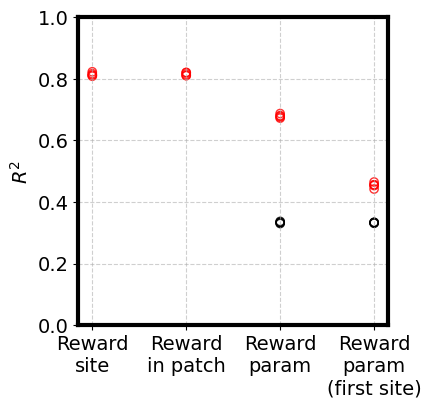

In [79]:
scale = 1
fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale))
all_pred_accuracies = []

reg_types = [
    LinearRegression,
    LinearRegression,
    LogisticRegression,
]

for k in range(targets.shape[1]):
    pred_accuracies = []
    shuffled_pred_accuracies = []
    y = targets[:, k]
    
    kf = KFold(n_splits=5)
    for train_i, test_i in kf.split(hidden_states, y):
        # do normal regression
        if k == 2:
            classifier = reg_types[k](max_iter=int(1e6))
        else:
            classifier = reg_types[k]()
        reg = classifier.fit(hidden_states[train_i, :], y[train_i])
        pred_accuracies.append(reg.score(hidden_states[test_i, :], y[test_i]))
        # do regression with shuffled labels
        y_test = y[test_i]
        np.random.shuffle(y_test)
        shuffled_pred_accuracies.append(reg.score(hidden_states[test_i, :], y_test))

    
    all_pred_accuracies.append(pred_accuracies)
    axs.scatter(np.ones(5) * k, pred_accuracies, alpha=0.8, facecolor='none', edgecolor='red')
    print(shuffled_pred_accuracies)
    axs.scatter(np.ones(5) * k, shuffled_pred_accuracies, alpha=0.8, facecolor='none', edgecolor='black')

for k in range(first_site_targets.shape[1]):
    pred_accuracies = []
    shuffled_pred_accuracies = []
    y = first_site_targets[:, k]
    
    kf = KFold(n_splits=5)
    for train_i, test_i in kf.split(first_site_hidden_states, y):
        classifier = LogisticRegression(max_iter=int(1e6))
        reg = classifier.fit(first_site_hidden_states[train_i, :], y[train_i])
        pred_accuracies.append(reg.score(first_site_hidden_states[test_i, :], y[test_i]))
        # do regression with shuffled labels
        y_test = y[test_i]
        np.random.shuffle(y_test)
        shuffled_pred_accuracies.append(reg.score(first_site_hidden_states[test_i, :], y_test))

    all_pred_accuracies.append(pred_accuracies)
    x = np.ones(5) * k + targets.shape[1]
    axs.scatter(x, pred_accuracies, alpha=0.8, facecolor='none', edgecolor='red')
    print(shuffled_pred_accuracies)
    axs.scatter(x, shuffled_pred_accuracies, alpha=0.8, facecolor='none', edgecolor='black')


axs.set_ylabel(r'$R^2$')
axs.set_xticks(np.arange(targets.shape[1] + first_site_targets.shape[1]))
axs.set_xticklabels([
    'Reward\nsite',
    'Reward\nin patch',
    'Reward\nparam',
    'Reward\nparam\n(first site)',
])
axs.grid(True, linestyle='--', alpha=0.6)
axs.set_ylim(0, 1)
    

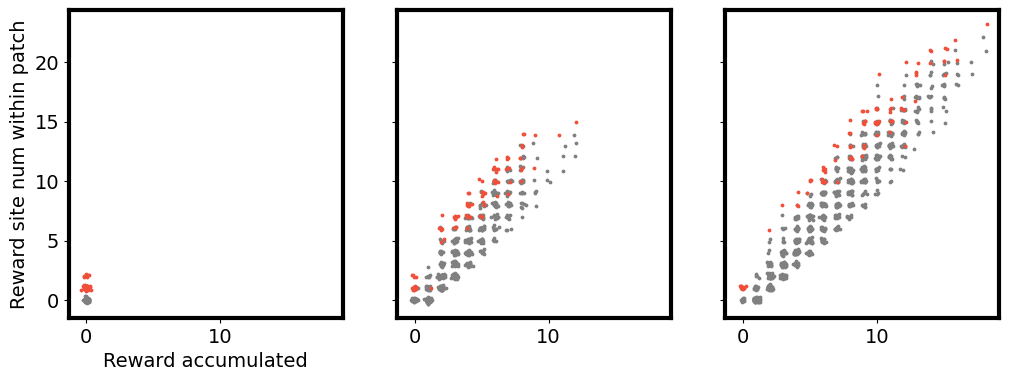

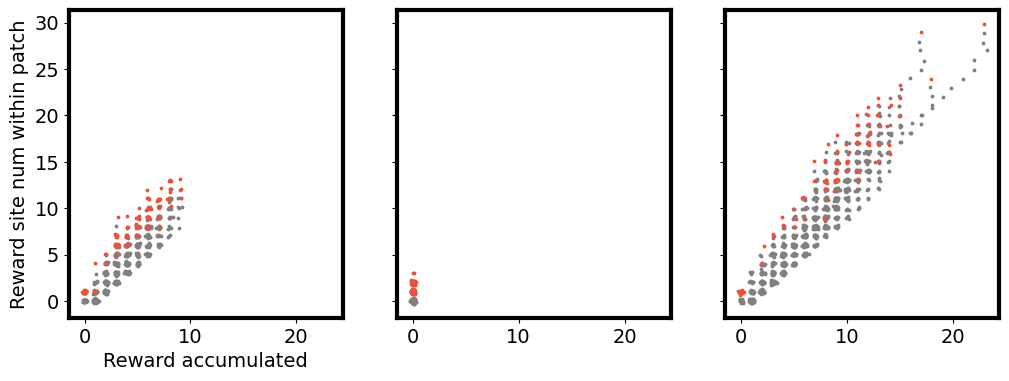

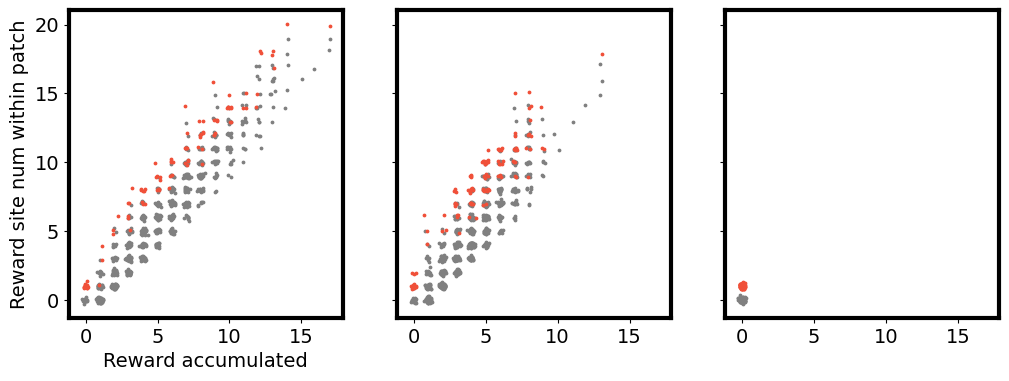

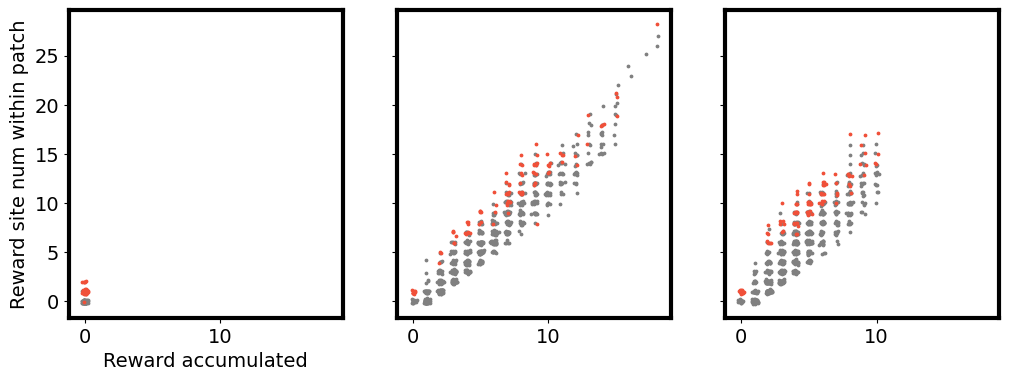

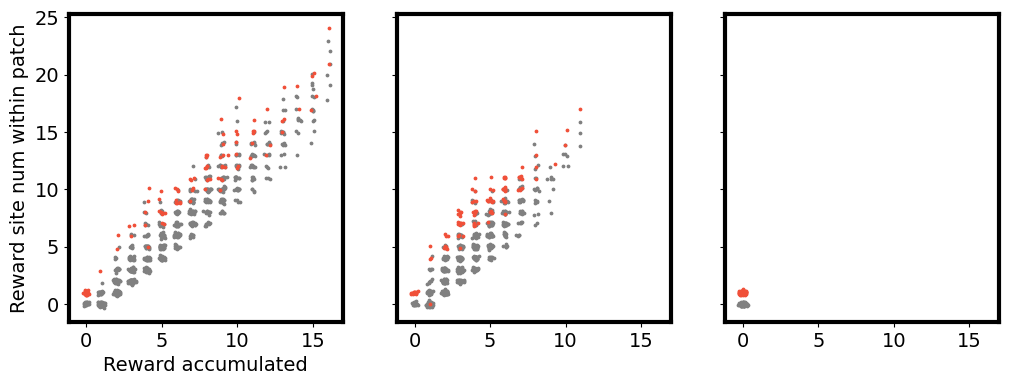

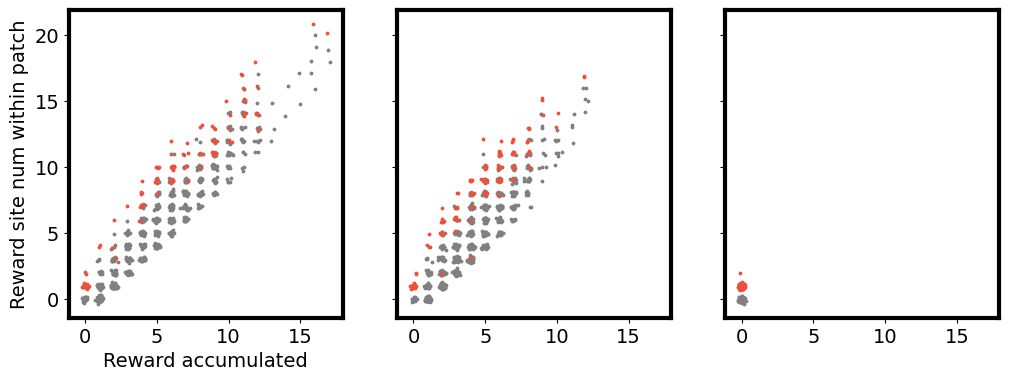

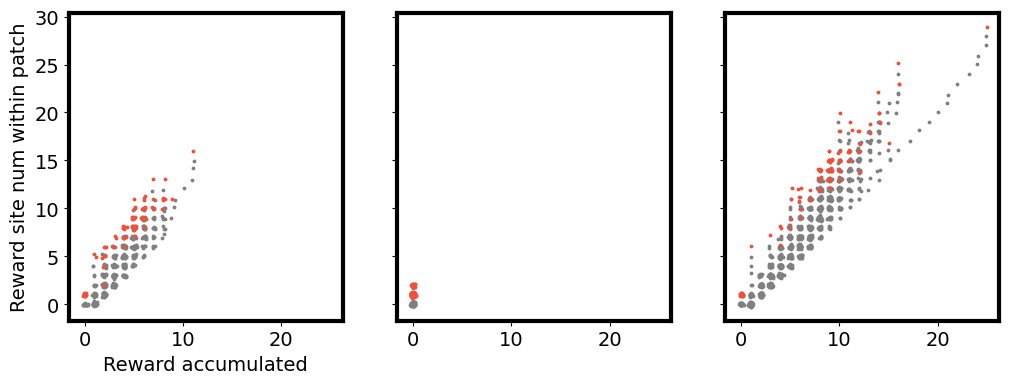

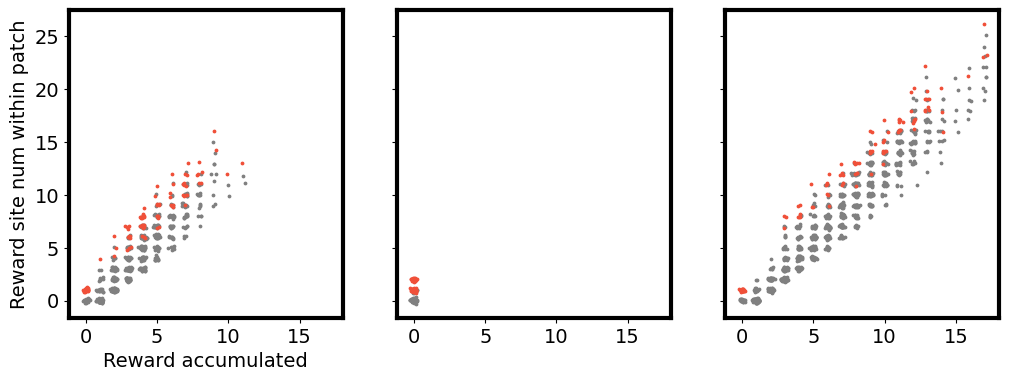

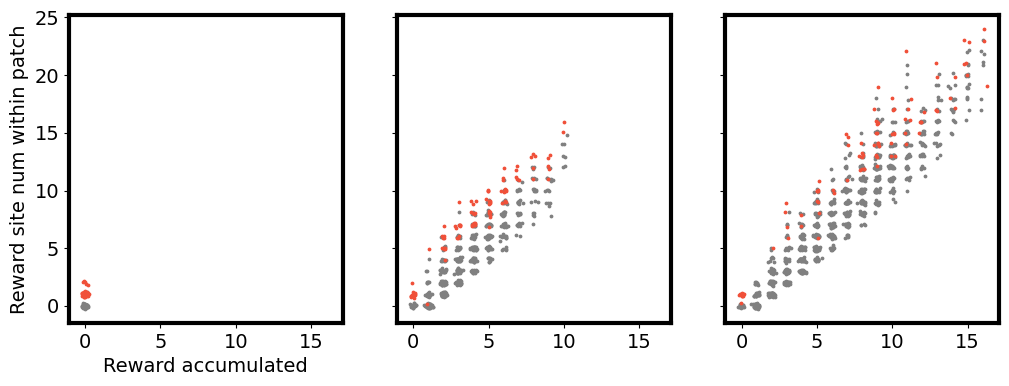

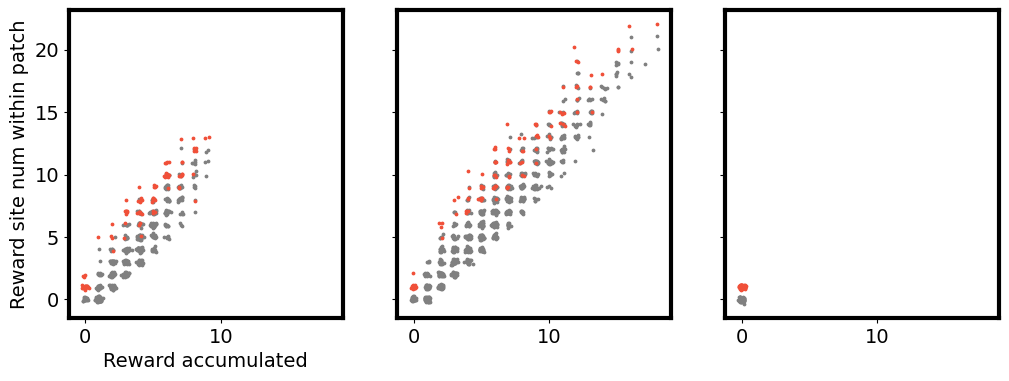

In [63]:
for env_idx in np.arange(10):
    scale = 1
    fig, axs = plt.subplots(1, 3, figsize=(12 * scale, 4 * scale), sharex=True, sharey=True)
    
    session_data = all_session_data[env_idx]
    trajs_by_patch_type = find_odor_site_trajectories_by_patch_type(session_data)
    
    for k in range(3):
        pred_accuracies = []   
        leave = []
        reward_accumulated = []
        reward_site_indices = []
        
        last_reward_site_idx = None
        last_reward_accumulated_within_patch = None
        for i in range(len(trajs_by_patch_type[k])):
            reward_site_idx = session_data['reward_site_idx'][trajs_by_patch_type[k][i]][0]
            if last_reward_site_idx is not None:
                if last_reward_site_idx >= reward_site_idx:
                    leave.append(True)
                else:
                    leave.append(False)
                reward_accumulated.append(last_reward_accumulated_within_patch)
                reward_site_indices.append(last_reward_site_idx)
            last_reward_site_idx = reward_site_idx
            last_reward_accumulated_within_patch = session_data['rewards_seen_in_patch'][trajs_by_patch_type[k][i]][-1]

        if last_reward_site_idx is not None:
            if last_reward_site_idx >= reward_site_idx:
                leave.append(True)
            else:
                leave.append(False)
            reward_accumulated.append(last_reward_accumulated_within_patch)
            reward_site_indices.append(last_reward_site_idx)
    
        leave = np.array(leave)
        reward_site_indices = np.array(reward_site_indices)
        reward_accumulated = np.array(reward_accumulated)
    
        var = 0.1
        noise_leave_x =  var * np.random.normal(size=np.count_nonzero(leave))
        noise_leave_y =  var * np.random.normal(size=np.count_nonzero(leave))
        noise_stay_x = var *  np.random.normal(size=np.count_nonzero(~leave))
        noise_stay_y =  var * np.random.normal(size=np.count_nonzero(~leave))
    
        axs[k].scatter(reward_accumulated[leave] + noise_leave_x, reward_site_indices[leave] + noise_leave_y, color='#f05039', s=3, alpha=1)
        axs[k].scatter(reward_accumulated[~leave] + noise_stay_x, reward_site_indices[~leave] + noise_stay_y, color='grey', s=3, zorder=-1, alpha=1)
    
    # print(pred_accuracies)
    # axs.set_ylim(0, 1.1)
    # axs.set_ylabel(r'$R^2$')
    axs[0].set_xlabel('Reward accumulated')
    axs[0].set_ylabel('Reward site num within patch')

    # patch_reward_params = np.unique(session_data['patch_reward_param'])
    # axs.set_title(', '.join([f'{int(pr * 10) / 10}' for pr in patch_reward_params]))
    # axs.set_title('Stay')

    # axs[0].set_xlim(-0.5, 8.5)
    # axs[0].set_ylim(-0.5, 8.5) 
        
# axs.set_title('Decoding total reward received\nin current patch from hidden state')

covariates = np.stack([reward_accumulated, reward_site_indices]).T

(2407, 2)
(2407,)
0.9066390041493776
0.9066390041493776
0.9064449064449065
0.9126819126819127
0.6902286902286903


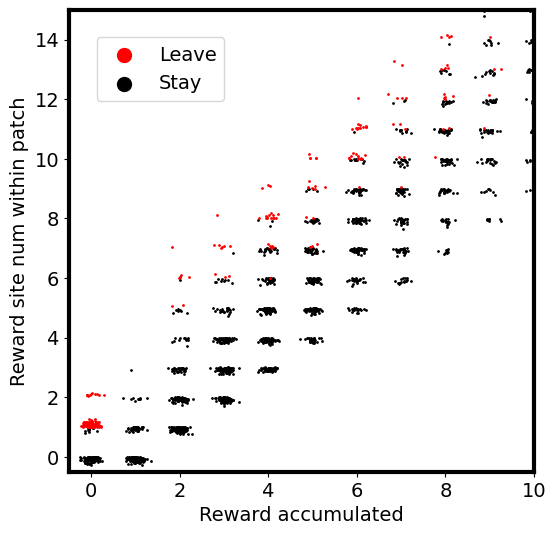

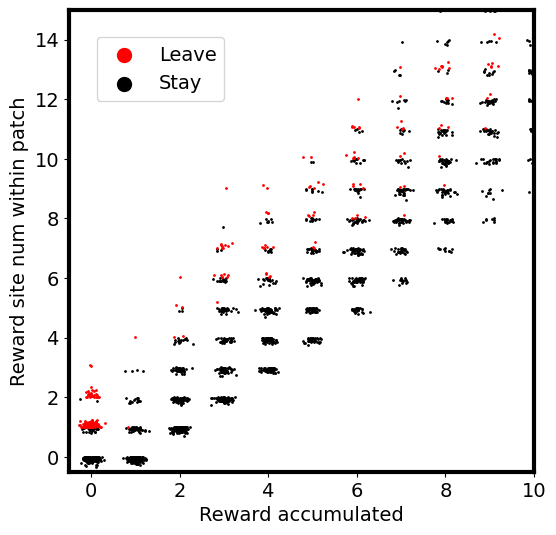

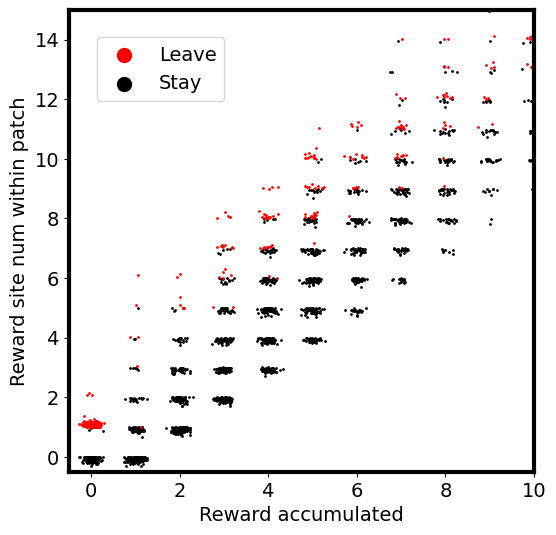

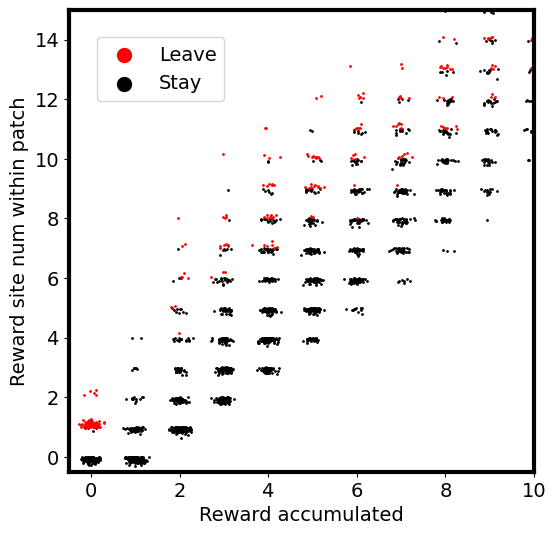

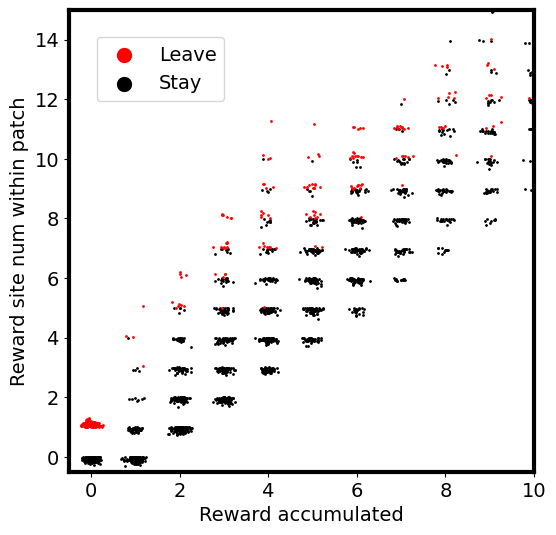

In [96]:
for env_idx in np.arange(5):
    scale = 1.5
    fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale), sharex=True, sharey=True)
    
    pred_accuracies = []
        
    leave = []
    reward_accumulated = []
    reward_site_indices = []
    
    session_data = all_session_data[env_idx]
    trajs_by_patch_type = find_odor_site_trajectories_by_patch_type(session_data)
    for k in range(3):
        last_reward_site_idx = None
        last_reward_accumulated_within_patch = None
        for i in range(len(trajs_by_patch_type[k])):
            reward_site_idx = session_data['reward_site_idx'][trajs_by_patch_type[k][i]][0]
            if last_reward_site_idx is not None:
                if last_reward_site_idx > reward_site_idx:
                    leave.append(True)
                else:
                    leave.append(False)
                reward_accumulated.append(last_reward_accumulated_within_patch)
                reward_site_indices.append(last_reward_site_idx)
            last_reward_site_idx = reward_site_idx
            last_reward_accumulated_within_patch = session_data['rewards_seen_in_patch'][trajs_by_patch_type[k][i]][-1]
    
    leave = np.array(leave)
    reward_site_indices = np.array(reward_site_indices)
    reward_accumulated = np.array(reward_accumulated)
    
    var = 0.1
    noise_leave_x =  var * np.random.normal(size=np.count_nonzero(leave))
    noise_leave_y =  var * np.abs(np.random.normal(size=np.count_nonzero(leave)))
    noise_stay_x = var *  np.random.normal(size=np.count_nonzero(~leave))
    noise_stay_y =  var * -np.abs(np.random.normal(size=np.count_nonzero(~leave)))
    
    axs.scatter(reward_accumulated[leave] + noise_leave_x, reward_site_indices[leave] + noise_leave_y, color='red', s=1, alpha=1, label='Leave')
    axs.scatter(reward_accumulated[~leave] + noise_stay_x, reward_site_indices[~leave] + noise_stay_y, color='black', s=1, zorder=-1, alpha=1, label='Stay')
    
    # print(pred_accuracies)
    # axs.set_ylim(0, 1.1)
    # axs.set_ylabel(r'$R^2$')
    axs.set_xlabel('Reward accumulated')
    axs.set_ylabel('Reward site num within patch')

    patch_reward_params = np.unique(session_data['patch_reward_param'])
    # axs.set_title(', '.join([f'{int(pr * 10) / 10}' for pr in patch_reward_params]))
    # axs.set_title('Stay')

    axs.set_xlim(-0.5, 10)
    axs.set_ylim(-0.5, 15)

    fig.legend(markerscale=10, bbox_to_anchor=(0.4, 0.85))
        
# axs.set_title('Decoding total reward received\nin current patch from hidden state')

covariates = np.stack([reward_accumulated, reward_site_indices]).T

print(covariates.shape)
print(leave.shape)

kf = KFold(n_splits=5)
for train_i, test_i in kf.split(covariates, leave):
    reg = LogisticRegression().fit(covariates[train_i, :], leave[train_i])
    print(reg.score(covariates[test_i, :], leave[test_i]))

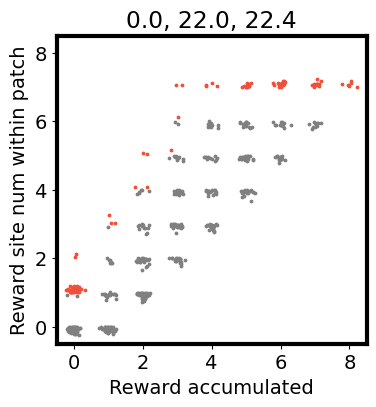

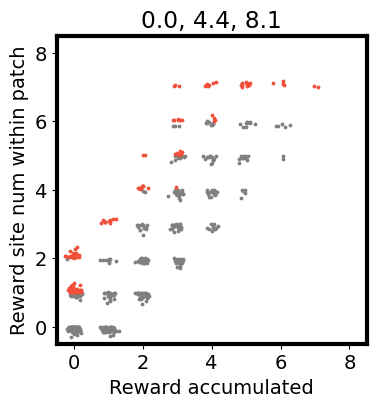

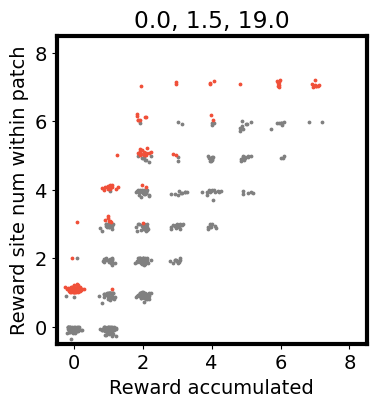

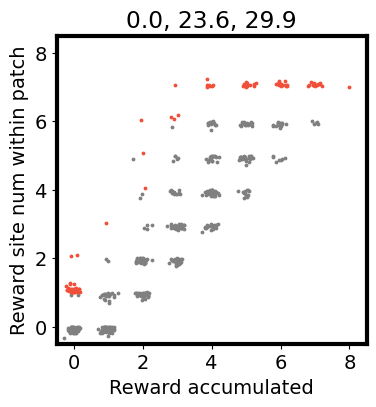

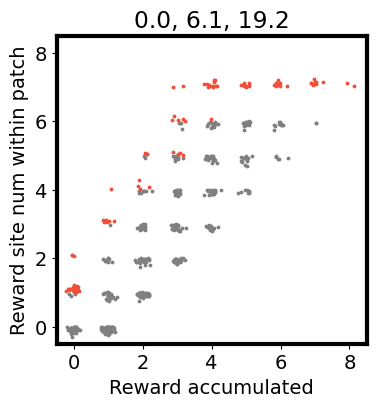

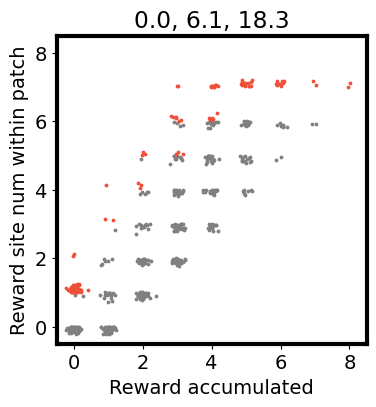

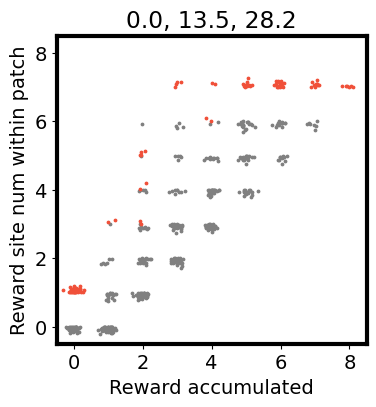

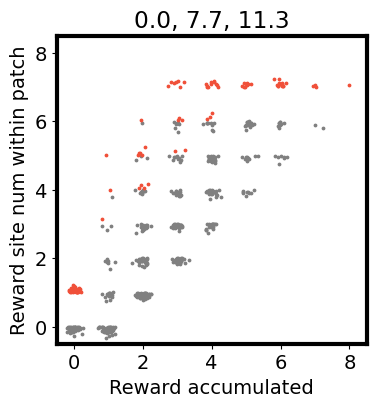

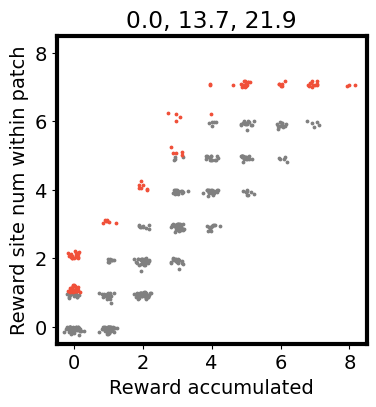

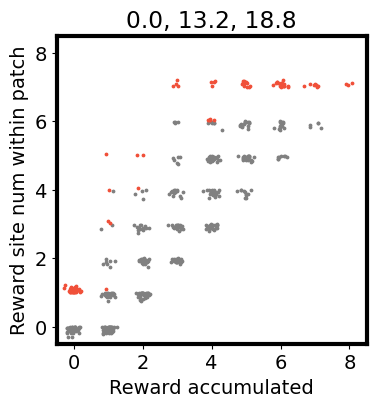

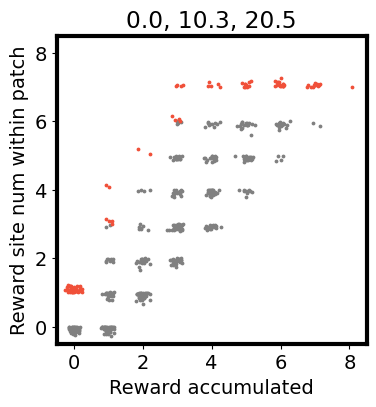

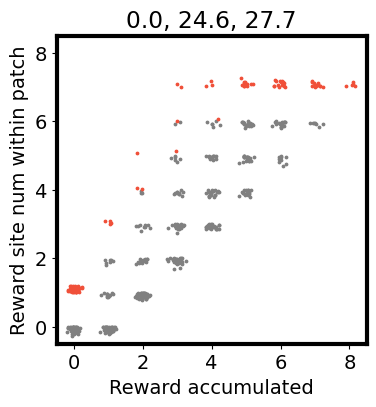

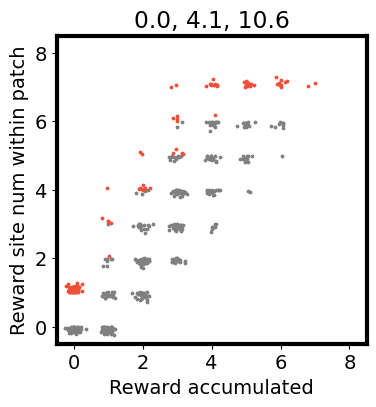

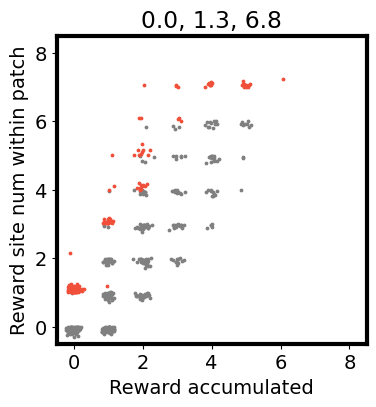

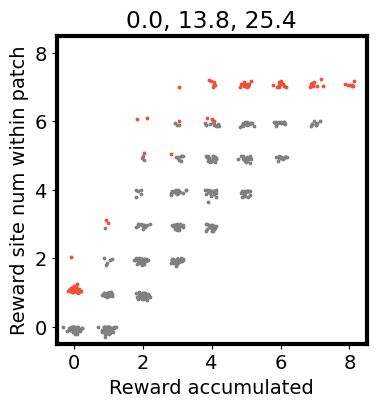

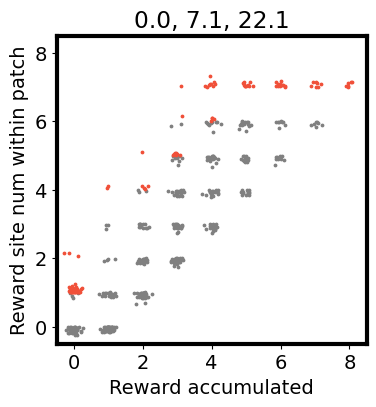

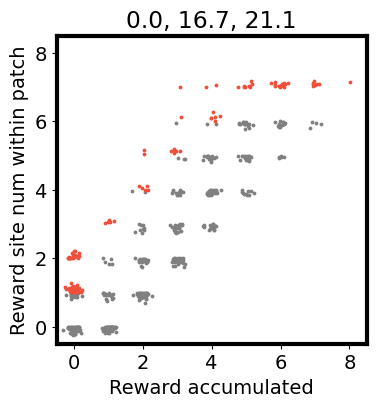

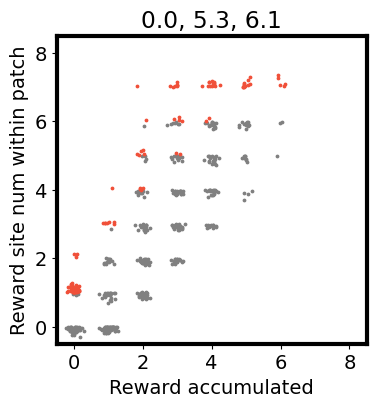

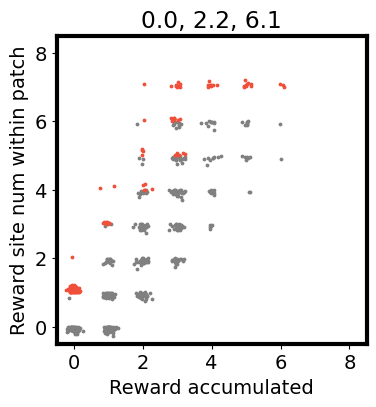

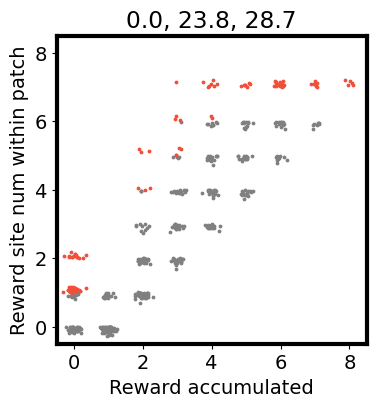

In [18]:
for env_idx in np.arange(20):
    scale = 1
    fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale), sharex=True, sharey=True)
    
    pred_accuracies = []
        
    leave = []
    reward_accumulated = []
    reward_site_indices = []
    
    session_data = all_session_data[env_idx]
    trajs_by_patch_type = find_odor_site_trajectories_by_patch_type(session_data)
    for k in range(3):
        last_reward_site_idx = None
        last_reward_accumulated_within_patch = None
        for i in range(len(trajs_by_patch_type[k])):
            reward_site_idx = session_data['reward_site_idx'][trajs_by_patch_type[k][i]][0]
            if last_reward_site_idx is not None:
                if last_reward_site_idx > reward_site_idx:
                    leave.append(True)
                else:
                    leave.append(False)
                reward_accumulated.append(last_reward_accumulated_within_patch)
                reward_site_indices.append(last_reward_site_idx)
            last_reward_site_idx = reward_site_idx
            last_reward_accumulated_within_patch = session_data['rewards_seen_in_patch'][trajs_by_patch_type[k][i]][-1]
    
    leave = np.array(leave)
    reward_site_indices = np.array(reward_site_indices)
    reward_accumulated = np.array(reward_accumulated)
    
    var = 0.1
    noise_leave_x =  var * np.random.normal(size=np.count_nonzero(leave))
    noise_leave_y =  var * np.abs(np.random.normal(size=np.count_nonzero(leave)))
    noise_stay_x = var *  np.random.normal(size=np.count_nonzero(~leave))
    noise_stay_y =  var * -np.abs(np.random.normal(size=np.count_nonzero(~leave)))
    
    axs.scatter(reward_accumulated[leave] + noise_leave_x, reward_site_indices[leave] + noise_leave_y, color='#f05039', s=3, alpha=1)
    axs.scatter(reward_accumulated[~leave] + noise_stay_x, reward_site_indices[~leave] + noise_stay_y, color='grey', s=3, zorder=-1, alpha=1)
    
    # print(pred_accuracies)
    # axs.set_ylim(0, 1.1)
    # axs.set_ylabel(r'$R^2$')
    axs.set_xlabel('Reward accumulated')
    axs.set_ylabel('Reward site num within patch')

    patch_reward_params = np.unique(session_data['patch_reward_param'])
    axs.set_title(', '.join([f'{int(pr * 10) / 10}' for pr in patch_reward_params]))
    # axs.set_title('Stay')

    axs.set_xlim(-0.5, 8.5)
    axs.set_ylim(-0.5, 8.5) 
        
# axs.set_title('Decoding total reward received\nin current patch from hidden state')

# reg = LogisticRegression().fit(covariates[:40000], leave[:40000])
# print(reg.score(covariates[40000:], leave[40000:]))

In [97]:
data = load_numpy('../../results/rl_agent_outputs/structural_priors_in_rl_low_noise_optim_01_test_2025-01-08_10_52_23_295387_var_noise_0.0001_activity_weight_1.0/hidden_state/*.npy')
all_session_data = parse_session('../../results/rl_agent_outputs/structural_priors_in_rl_low_noise_optim_01_test_2025-01-08_10_52_23_295387_var_noise_0.0001_activity_weight_1.0/state')
all_session_data = np.array(all_session_data)
print(all_session_data.shape)

['00000.pkl', '00001.pkl', '00002.pkl', '00003.pkl', '00004.pkl', '00005.pkl', '00006.pkl', '00007.pkl']
(240,)


In [98]:
hidden_states = []
targets = []

for env_idx in range(0, 240):
    session_data = all_session_data[env_idx]
    trajs_by_patch_type = find_odor_site_trajectories_by_patch_type(session_data)
    for k in range(3):
        trajs_for_patch_type = trajs_by_patch_type[k]
        for i in range(len(trajs_for_patch_type)):
            if i < 100:
                curr_traj = trajs_for_patch_type[i]
                hidden_states.append(data[curr_traj, env_idx, :])
                targets.append(np.array([
                    session_data['reward_site_idx'][curr_traj],
                    session_data['rewards_seen_in_patch'][curr_traj],
                    session_data['patch_reward_param'][curr_traj],
                ]))

hidden_states = np.concatenate(hidden_states, axis=0)
targets = np.concatenate(targets, axis=1).T

first_site_hidden_states = []
first_site_targets = []

for env_idx in range(0, 240):
    session_data = all_session_data[env_idx]
    trajs_by_patch_type = find_odor_site_trajectories_by_patch_type(session_data, first_site_only=True)
    for k in range(3):
        trajs_for_patch_type = trajs_by_patch_type[k]
        for i in range(len(trajs_for_patch_type)):
            if i < 100:
                curr_traj = trajs_for_patch_type[i]
                first_site_hidden_states.append(data[curr_traj, env_idx, :])
                first_site_targets.append(np.array([
                    session_data['patch_reward_param'][curr_traj],
                ]))

first_site_hidden_states = np.concatenate(first_site_hidden_states, axis=0)
first_site_targets = np.concatenate(first_site_targets, axis=1).T

[-0.8681007963374854, -0.8264420129548118, -0.8192203631143189, -0.862342002406387, -0.8338337739983632]
[-0.8566985729310166, -0.8362171372209122, -0.7956533858585966, -0.8810722592167648, -0.8385460233139723]
[0.36430503632108446, 0.36620467462995043, 0.3630491937812495, 0.36434096746250055, 0.3649336636221334]
[0.37595832658887235, 0.377900731344821, 0.3777535794693703, 0.3723383904527863, 0.3772091175302029]


(0.0, 1.0)

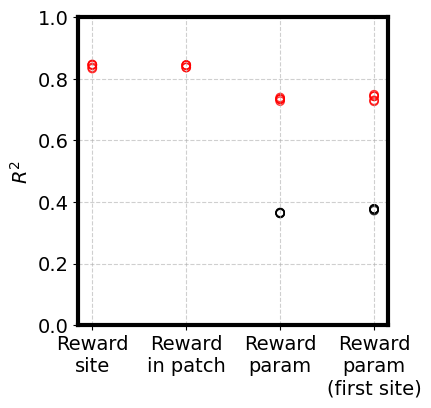

In [99]:
scale = 1
fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale))
all_pred_accuracies = []

reg_types = [
    LinearRegression,
    LinearRegression,
    LogisticRegression,
]

for k in range(targets.shape[1]):
    pred_accuracies = []
    shuffled_pred_accuracies = []
    y = targets[:, k]
    
    kf = KFold(n_splits=5)
    for train_i, test_i in kf.split(hidden_states, y):
        # do normal regression
        if k == 2:
            classifier = reg_types[k](max_iter=int(1e6))
        else:
            classifier = reg_types[k]()
        reg = classifier.fit(hidden_states[train_i, :], y[train_i])
        pred_accuracies.append(reg.score(hidden_states[test_i, :], y[test_i]))
        # do regression with shuffled labels
        y_test = y[test_i]
        np.random.shuffle(y_test)
        shuffled_pred_accuracies.append(reg.score(hidden_states[test_i, :], y_test))

    
    all_pred_accuracies.append(pred_accuracies)
    axs.scatter(np.ones(5) * k, pred_accuracies, alpha=0.8, facecolor='none', edgecolor='red')
    print(shuffled_pred_accuracies)
    axs.scatter(np.ones(5) * k, shuffled_pred_accuracies, alpha=0.8, facecolor='none', edgecolor='black')

for k in range(first_site_targets.shape[1]):
    pred_accuracies = []
    shuffled_pred_accuracies = []
    y = first_site_targets[:, k]
    
    kf = KFold(n_splits=5)
    for train_i, test_i in kf.split(first_site_hidden_states, y):
        classifier = LogisticRegression(max_iter=int(1e6))
        reg = classifier.fit(first_site_hidden_states[train_i, :], y[train_i])
        pred_accuracies.append(reg.score(first_site_hidden_states[test_i, :], y[test_i]))
        # do regression with shuffled labels
        y_test = y[test_i]
        np.random.shuffle(y_test)
        shuffled_pred_accuracies.append(reg.score(first_site_hidden_states[test_i, :], y_test))

    all_pred_accuracies.append(pred_accuracies)
    x = np.ones(5) * k + targets.shape[1]
    axs.scatter(x, pred_accuracies, alpha=0.8, facecolor='none', edgecolor='red')
    print(shuffled_pred_accuracies)
    axs.scatter(x, shuffled_pred_accuracies, alpha=0.8, facecolor='none', edgecolor='black')


axs.set_ylabel(r'$R^2$')
axs.set_xticks(np.arange(targets.shape[1] + first_site_targets.shape[1]))
axs.set_xticklabels([
    'Reward\nsite',
    'Reward\nin patch',
    'Reward\nparam',
    'Reward\nparam\n(first site)',
])
axs.grid(True, linestyle='--', alpha=0.6)
axs.set_ylim(0, 1)